<a href="https://colab.research.google.com/github/Tayli05/INTELIGENCIA-ARTIFICIAL-1/blob/main/Lab5_onevsall_fashionmnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificación Multiclase con Regresión Logística: One-vs-All
## Reconocimiento de prendas de vestir — Fashion-MNIST

En este cuaderno se implementa un clasificador multiclase mediante la estrategia **One-vs-All** (uno contra todos) usando Regresión Logística, con `numpy`, `pandas` y `matplotlib (sin Scikit-Learn).

**Dataset:** Fashion-MNIST — imágenes de prendas de vestir en escala de grises de **28x28 píxeles** (784 valores por imagen al aplanarse), agrupadas en **10 clases**.

**Flujo de trabajo:**
1. Carga del dataset (imágenes 28x28, m = 70,000).
2. Preprocesamiento con Pandas (nulos, duplicados, columnas).
3. Verificación de balanceo de clases.
4. Normalización de los píxeles.
5. División 80% entrenamiento / 20% prueba.
6. Entrenamiento One-vs-All (10 clasificadores binarios) y curvas de costo.
7. Evaluación: accuracy global, por clase, y ejemplos visuales de predicción.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np              # calculo vectorial y numerico
import pandas as pd             # manejo de datos tabulares
from matplotlib import pyplot   # graficacion
from PIL import Image           # lectura de imagenes PNG
import os

%matplotlib inline

## 1. Dataset

Fashion-MNIST contiene 10 categorías de prendas: *T-shirt/top: Camiseta / Top, Trouser: Pantalón, Pullover: Jersey / Pulóver, Dress:Vestido, Coat: Abrigo, Sandal: Sandalia, Shirt: Camisa, Sneaker: Zapatilla / Tenis, Bag: Bolso / Mochila, Ankle boot: Botín*.
 Cada imagen es de **28x28 píxeles** en escala de grises, lo que da **784 características** por ejemplo al aplanarse en un vector.

El dataset se encuentra en formato **PNG** organizado en subcarpetas por clase (`0` a `9`), guardado en Google Drive dentro de la carpeta `Fashion-MNIST`, con dos subcarpetas principales `train` y `test`.

In [3]:
RUTA_BASE = '/content/drive/MyDrive/InteligenciaArtificial/Fashion-MNIST'
RUTA_TRAIN = os.path.join(RUTA_BASE, 'train')
RUTA_TEST  = os.path.join(RUTA_BASE, 'test')

print('Subcarpetas en train:', sorted(os.listdir(RUTA_TRAIN)))
print('Subcarpetas en test: ', sorted(os.listdir(RUTA_TEST)))

Subcarpetas en train: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Subcarpetas en test:  ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


In [4]:
nombres_clases = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                   'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

def cargar_carpeta(ruta_split):
    # Recorre las 10 subcarpetas (una por clase, nombradas 0-9) dentro de train o test
    # y devuelve X (imagenes aplanadas) e y (etiquetas numericas 0-9)
    subcarpetas = sorted(os.listdir(ruta_split), key=lambda s: int(s))  # ['0','1',...,'9'] en orden numerico
    imagenes = []
    etiquetas = []

    for subcarpeta in subcarpetas:
        clase_idx = int(subcarpeta)
        ruta_clase = os.path.join(ruta_split, subcarpeta)
        archivos_png = [f for f in os.listdir(ruta_clase) if f.lower().endswith('.png')]

        for nombre_archivo in archivos_png:
            img = Image.open(os.path.join(ruta_clase, nombre_archivo)).convert('L')  # escala de grises
            arr = np.array(img).flatten()  # aplana a 784 (28x28)
            imagenes.append(arr)
            etiquetas.append(clase_idx)

        print('Clase {} ({}) -> {} imagenes cargadas'.format(
            clase_idx, nombres_clases[clase_idx], len(archivos_png)))

    return np.array(imagenes, dtype=np.uint8), np.array(etiquetas, dtype=int)

X_train_raw, y_train_raw = cargar_carpeta(RUTA_TRAIN)
X_test_raw,  y_test_raw  = cargar_carpeta(RUTA_TEST)

# se combinan train+test originales; nuestra propia division 80/20 se hace despues
X = np.concatenate([X_train_raw, X_test_raw], axis=0)
y = np.concatenate([y_train_raw, y_test_raw], axis=0)

filas, columnas = 28, 28  # tamano de cada imagen Fashion-MNIST

print('X:', X.shape, ' y:', y.shape)
print('Total de ejemplos m =', X.shape[0])

Clase 0 (T-shirt/top) -> 6013 imagenes cargadas
Clase 1 (Trouser) -> 6000 imagenes cargadas
Clase 2 (Pullover) -> 6000 imagenes cargadas
Clase 3 (Dress) -> 6000 imagenes cargadas
Clase 4 (Coat) -> 6000 imagenes cargadas
Clase 5 (Sandal) -> 6000 imagenes cargadas
Clase 6 (Shirt) -> 6000 imagenes cargadas
Clase 7 (Sneaker) -> 6000 imagenes cargadas
Clase 8 (Bag) -> 6000 imagenes cargadas
Clase 9 (Ankle boot) -> 6000 imagenes cargadas
Clase 0 (T-shirt/top) -> 1000 imagenes cargadas
Clase 1 (Trouser) -> 1000 imagenes cargadas
Clase 2 (Pullover) -> 1000 imagenes cargadas
Clase 3 (Dress) -> 1000 imagenes cargadas
Clase 4 (Coat) -> 1000 imagenes cargadas
Clase 5 (Sandal) -> 1000 imagenes cargadas
Clase 6 (Shirt) -> 1000 imagenes cargadas
Clase 7 (Sneaker) -> 1000 imagenes cargadas
Clase 8 (Bag) -> 1000 imagenes cargadas
Clase 9 (Ankle boot) -> 1000 imagenes cargadas
X: (70013, 784)  y: (70013,)
Total de ejemplos m = 70013


Se muestran algunos ejemplos del dataset para verificar que la carga fue correcta.

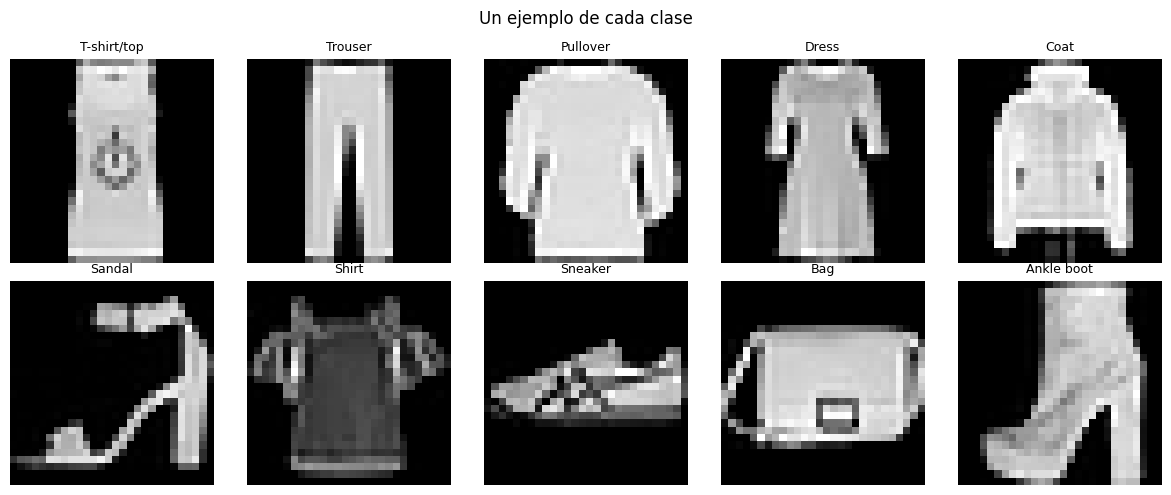

In [5]:
fig, axes = pyplot.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    idx = np.where(y == i)[0][0]
    ax.imshow(X[idx].reshape(filas, columnas), cmap='gray')
    ax.set_title(nombres_clases[i], fontsize=9)
    ax.axis('off')
pyplot.suptitle('Un ejemplo de cada clase')
pyplot.tight_layout()
pyplot.show()

### Mosaico de muestra aleatoria

Además del ejemplo por clase ya mostrado, se construye una función `displayData` (inspirada en el material de clase) que arma un **mosaico** con una muestra aleatoria de imágenes del dataset, útil para verificar visualmente que la carga desde Drive fue correcta antes de continuar con el preprocesamiento.

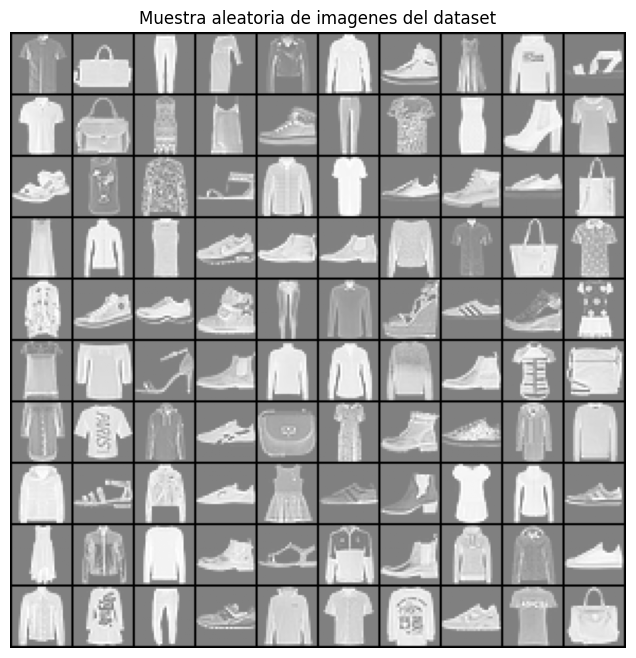

In [6]:
def displayData(X, example_width=None, figsize=(8, 8)):
    # Arma un mosaico con las imagenes (filas de X) y lo muestra en escala de grises
    if X.ndim == 2:
        m, n = X.shape
    elif X.ndim == 1:
        n = X.size
        m = 1
        X = X[None]
    else:
        raise IndexError('X debe ser 1 o 2 dimensional.')

    example_width = example_width or int(np.round(np.sqrt(n)))
    example_height = n // example_width

    display_rows = int(np.floor(np.sqrt(m)))
    display_cols = int(np.ceil(m / display_rows))

    pad = 1
    display_array = -np.ones((pad + display_rows * (example_height + pad),
                               pad + display_cols * (example_width + pad)))

    curr_ex = 0
    for j in range(display_rows):
        for i in range(display_cols):
            if curr_ex >= m:
                break
            max_val = max(np.abs(X[curr_ex, :].max()), 1)
            fila_ini = pad + j * (example_height + pad)
            col_ini = pad + i * (example_width + pad)
            display_array[fila_ini:fila_ini + example_height, col_ini:col_ini + example_width] = (
                X[curr_ex].reshape(example_height, example_width) / max_val)
            curr_ex += 1
        if curr_ex >= m:
            break

    pyplot.figure(figsize=figsize)
    pyplot.imshow(display_array, cmap='gray', extent=[-1, 1, -1, 1])
    pyplot.axis('off')
    pyplot.title('Muestra aleatoria de imagenes del dataset')
    pyplot.show()


np.random.seed(3)
indices_aleatorios = np.random.choice(X.shape[0], 100, replace=False)
muestra = X[indices_aleatorios, :]
displayData(muestra, example_width=columnas)

## 2. Preprocesamiento con Pandas

Se construye un `DataFrame` de Pandas con una columna por cada pixel (`pixel_0` ... `pixel_783`) más la columna `label`, para poder inspeccionar y limpiar los datos con las herramientas propias de Pandas.

### 2.1 Valores nulos y duplicados

In [7]:
nombres_columnas_px = ['pixel_' + str(i) for i in range(X.shape[1])]
df = pd.DataFrame(X, columns=nombres_columnas_px)
df['label'] = y

print('Dimensiones del DataFrame:', df.shape)
print('Valores nulos totales:', df.isnull().sum().sum())
print('Filas completamente duplicadas:', df.duplicated().sum())

Dimensiones del DataFrame: (70013, 785)
Valores nulos totales: 0
Filas completamente duplicadas: 13




### 2.2 ¿Qué columnas se quitaron y qué se conservó?

En datasets de imágenes es común encontrar píxeles de borde que **siempre valen 0** (fondo) en todas las imágenes: esos píxeles no aportan información para diferenciar clases y se pueden eliminar. Se calcula la varianza de cada columna de píxeles para detectarlos.

In [8]:
varianzas = df[nombres_columnas_px].var()
columnas_constantes = varianzas[varianzas == 0].index.tolist()

print('Columnas de pixeles con varianza 0 (sin informacion):', len(columnas_constantes))
print('Total de columnas de pixeles:', len(nombres_columnas_px))

Columnas de pixeles con varianza 0 (sin informacion): 0
Total de columnas de pixeles: 784


A diferencia del MNIST clásico de dígitos, en Fashion-MNIST **ningún píxel tiene varianza cero** — las prendas ocupan casi toda el área de la imagen, por lo que los 784 píxeles aportan información y **se conservan todos**. Esto confirma, con evidencia, que no es necesario descartar columnas en este dataset; de haber existido píxeles constantes, se habrían eliminado con `df.drop(columns=columnas_constantes)`.

Se separan nuevamente `X` (píxeles) y `y` (etiqueta) del DataFrame ya verificado, para continuar el procesamiento numérico con NumPy (más eficiente para el cálculo matricial del modelo).

In [9]:
X = df[nombres_columnas_px].values.astype(float)
y = df['label'].values.astype(int)

print('X:', X.shape, ' y:', y.shape)

X: (70013, 784)  y: (70013,)


## 3. Verificación de balanceo de clases

Se cuenta cuántos ejemplos hay de cada una de las 10 clases.

label
0    7013
1    7000
2    7000
3    7000
4    7000
5    7000
6    7000
7    7000
8    7000
9    7000
Name: count, dtype: int64


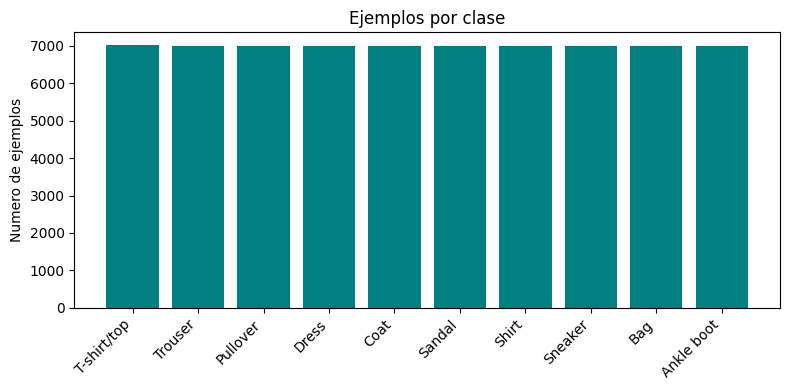

In [10]:
conteo_clases = df['label'].value_counts().sort_index()
print(conteo_clases)

pyplot.figure(figsize=(8, 4))
pyplot.bar([nombres_clases[i] for i in conteo_clases.index], conteo_clases.values, color='teal')
pyplot.ylabel('Numero de ejemplos')
pyplot.title('Ejemplos por clase')
pyplot.xticks(rotation=45, ha='right')
pyplot.tight_layout()
pyplot.show()

El dataset ya está **perfectamente balanceado**: exactamente **7,000 ejemplos por cada una de las 10 clases** (70,000 en total). Por lo tanto, **no se requiere aplicar ninguna técnica de balanceo** (undersampling/oversampling); de haber desbalance, se habría corregido igualando la cantidad de ejemplos por clase con `df.groupby('label').sample(n=n_min)` u otra técnica similar.

## 4. Normalización de datos

Cada píxel tiene un valor entero entre **0 y 255** (intensidad de gris). Aunque todos los píxeles ya comparten la misma unidad, un rango de 0-255 sigue siendo grande para el descenso por el gradiente: valores grandes generan gradientes grandes y desiguales entre sí, lo que puede provocar pasos de actualización inestables o una convergencia muy lenta.

Se aplica **escalamiento Min-Max**, dividiendo entre 255 para llevar todos los valores al rango **[0, 1]**:

$$ x^{norm} = \frac{x}{255} $$

Esto ayuda a que el gradiente descendente dé pasos de tamaño similar en todas las direcciones y converja de forma más rápida y estable, sin que ninguna característica domine sobre las demás solo por tener una escala numérica mayor.

In [11]:
X_norm = X / 255.0

print('Antes de normalizar -> min: {}, max: {}'.format(X.min(), X.max()))
print('Despues de normalizar -> min: {:.2f}, max: {:.2f}'.format(X_norm.min(), X_norm.max()))

Antes de normalizar -> min: 0.0, max: 255.0
Despues de normalizar -> min: 0.00, max: 1.00


## 5. División de datos: entrenamiento (80%) y prueba (20%)

Se mezclan aleatoriamente los índices (semilla fija para reproducibilidad) y se separa el **80%** para entrenar y el **20%** restante para evaluar. El conjunto de prueba **no se utiliza en ningún momento del entrenamiento**.

In [12]:
np.random.seed(42)
m = X_norm.shape[0]
indices = np.random.permutation(m)

train_size = int(0.8 * m)
train_idx, test_idx = indices[:train_size], indices[train_size:]

X_train, X_test = X_norm[train_idx], X_norm[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# se conservan tambien los pixeles originales (0-255) del set de prueba, solo para graficar despues
X_test_visual = X[test_idx]

print('Entrenamiento:', X_train.shape[0], ' | Prueba:', X_test.shape[0])

Entrenamiento: 56010  | Prueba: 14003


Se agrega la columna de unos (término de intercepción, $\theta_0$) a ambos conjuntos.

In [13]:
X_train = np.concatenate([np.ones((X_train.shape[0], 1)), X_train], axis=1)
X_test  = np.concatenate([np.ones((X_test.shape[0], 1)), X_test], axis=1)

m_train, n = X_train.shape
print('X_train con intercepcion:', X_train.shape)
print('X_test con intercepcion:', X_test.shape)

X_train con intercepcion: (56010, 785)
X_test con intercepcion: (14003, 785)


## 6. Implementación del modelo: Regresión Logística One-vs-All

### 6.1 Función sigmoide

$$g(z) = \frac{1}{1 + e^{-z}}$$

In [14]:
def sigmoid(z):
    z = np.clip(z, -500, 500)  # evita overflow numerico en exp()
    return 1 / (1 + np.exp(-z))

### 6.2 Función de costo (log-loss)

$$ J(\theta) = \frac{1}{m} \sum_{i=1}^{m} \left[ -y^{(i)} \log\left(h_\theta\left( x^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - h_\theta\left( x^{(i)} \right) \right) \right]$$

In [15]:
def calcularCosto(theta, X, y):
    m = y.size
    eps = 1e-10  # evita log(0)
    h = sigmoid(X.dot(theta))
    J = (1 / m) * np.sum(-y * np.log(h + eps) - (1 - y) * np.log(1 - h + eps))
    return J

### 6.3 Descenso por el gradiente

$$ \theta_j := \theta_j - \alpha \cdot \frac{1}{m} \sum_{i=1}^m \left( h_\theta \left( x^{(i)} \right) - y^{(i)} \right) x_j^{(i)} $$

In [16]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []
    for i in range(num_iters):
        h = sigmoid(X.dot(theta))
        theta = theta - (alpha / m) * (X.T.dot(h - y))
        J_history.append(calcularCosto(theta, X, y))
    return theta, J_history

### 6.4 Estrategia One-vs-All

Como hay **10 clases**, se entrena **un clasificador binario de regresión logística por cada clase**. Para entrenar el clasificador de la clase $c$, se construye una etiqueta binaria temporal: `1` si el ejemplo pertenece a la clase $c$, `0` si pertenece a cualquier otra clase. Al final se obtiene una matriz `all_theta` de tamaño `(10, 785)`, donde la fila $c$ contiene los parámetros $\theta$ del clasificador de la clase $c$.

In [17]:
def OneVsAll(X, y, num_labels, alpha, num_iters):
    m, n = X.shape
    all_theta = np.zeros((num_labels, n))
    all_J_history = []

    for c in range(num_labels):
        y_actual = np.where(y == c, 1, 0).astype(float)
        theta_inicial = np.zeros(n)
        theta, J_history = descensoGradiente(theta_inicial, X, y_actual, alpha, num_iters)
        all_theta[c] = theta
        all_J_history.append(J_history)
        print('Clasificador clase {} ({}) entrenado. Costo final: {:.4f}'.format(
            c, nombres_clases[c], J_history[-1]))

    return all_theta, all_J_history

## 7. Entrenamiento

Se entrenan los 10 clasificadores binarios sobre el conjunto de entrenamiento (56,000 ejemplos).

In [18]:
num_labels = 10
alpha = 1.0
num_iters = 500

all_theta, all_J_history = OneVsAll(X_train, y_train, num_labels, alpha, num_iters)
print('\nMatriz de parametros all_theta:', all_theta.shape)

Clasificador clase 0 (T-shirt/top) entrenado. Costo final: 0.2397
Clasificador clase 1 (Trouser) entrenado. Costo final: 0.0252
Clasificador clase 2 (Pullover) entrenado. Costo final: 0.6007
Clasificador clase 3 (Dress) entrenado. Costo final: 0.1125
Clasificador clase 4 (Coat) entrenado. Costo final: 0.5428
Clasificador clase 5 (Sandal) entrenado. Costo final: 0.0512
Clasificador clase 6 (Shirt) entrenado. Costo final: 0.5136
Clasificador clase 7 (Sneaker) entrenado. Costo final: 0.0520
Clasificador clase 8 (Bag) entrenado. Costo final: 0.0499
Clasificador clase 9 (Ankle boot) entrenado. Costo final: 0.0403

Matriz de parametros all_theta: (10, 785)


### Curvas de Costo vs. Iteraciones — una por cada clasificador

Se grafica la convergencia de cada uno de los 10 clasificadores binarios, superpuestas en una sola figura para comparar su comportamiento.

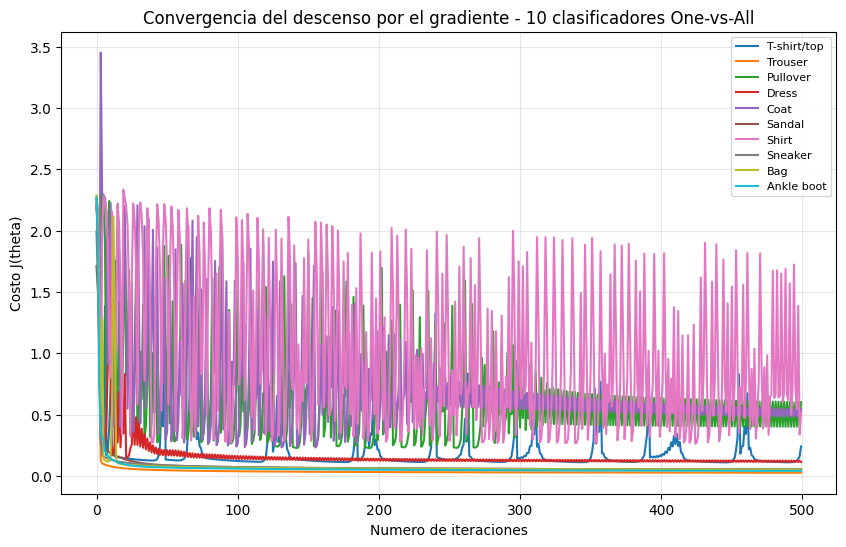

In [19]:
pyplot.figure(figsize=(10, 6))
for c in range(num_labels):
    pyplot.plot(np.arange(num_iters), all_J_history[c], label=nombres_clases[c])

pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J(theta)')
pyplot.title('Convergencia del descenso por el gradiente - 10 clasificadores One-vs-All')
pyplot.legend(loc='upper right', fontsize=8)
pyplot.grid(alpha=0.3)
pyplot.show()

También se muestran individualmente en una cuadrícula para apreciar mejor la convergencia de cada clasificador por separado.

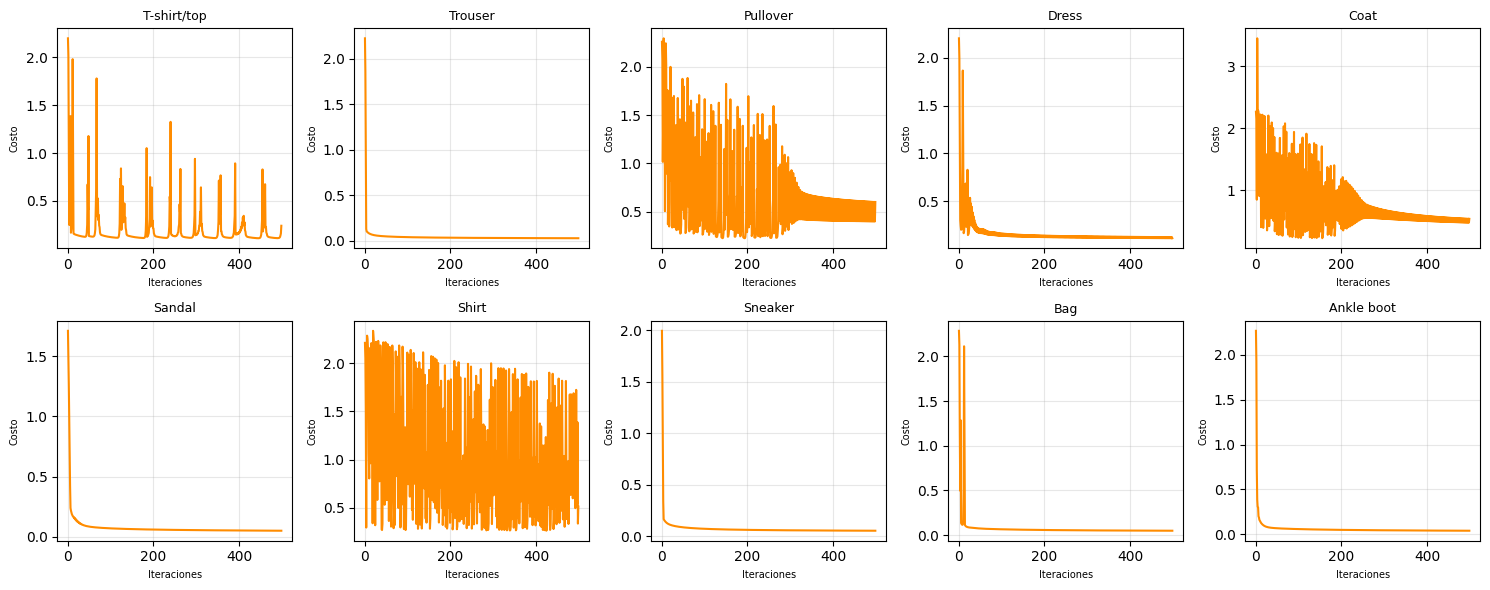

In [20]:
fig, axes = pyplot.subplots(2, 5, figsize=(15, 6))
for c, ax in enumerate(axes.flat):
    ax.plot(np.arange(num_iters), all_J_history[c], color='darkorange')
    ax.set_title(nombres_clases[c], fontsize=9)
    ax.set_xlabel('Iteraciones', fontsize=7)
    ax.set_ylabel('Costo', fontsize=7)
    ax.grid(alpha=0.3)
pyplot.tight_layout()
pyplot.show()

## 8. Evaluación sobre el conjunto de prueba

### 8.1 Predicción One-vs-All

Para cada ejemplo, se calcula la probabilidad de pertenecer a cada una de las 10 clases (usando los 10 vectores $\theta$ entrenados) y se elige la clase con la **mayor probabilidad** (`argmax`).

In [21]:
def predictOneVsAll(all_theta, X):
    probabilidades = sigmoid(X.dot(all_theta.T))
    predicciones = np.argmax(probabilidades, axis=1)
    return predicciones

pred_test = predictOneVsAll(all_theta, X_test)
pred_train = predictOneVsAll(all_theta, X_train)

### 8.2 Precisión (Accuracy) global

In [22]:
acc_train = np.mean(pred_train == y_train) * 100
acc_test = np.mean(pred_test == y_test) * 100

print('Precision en entrenamiento: {:.2f} %'.format(acc_train))
print('Precision en prueba:        {:.2f} %'.format(acc_test))

Precision en entrenamiento: 74.44 %
Precision en prueba:        74.51 %


### 8.3 Precisión por clase

Se calcula el accuracy de forma individual para cada una de las 10 clases sobre el conjunto de prueba, para identificar qué prendas confunde más el modelo.

T-shirt/top     -> Precision: 40.11 % (1451 ejemplos)
Trouser         -> Precision: 95.16 % (1445 ejemplos)
Pullover        -> Precision: 33.18 % (1344 ejemplos)
Dress           -> Precision: 89.72 % (1449 ejemplos)
Coat            -> Precision: 26.35 % (1393 ejemplos)
Sandal          -> Precision: 90.83 % (1374 ejemplos)
Shirt           -> Precision: 87.83 % (1381 ejemplos)
Sneaker         -> Precision: 92.36 % (1413 ejemplos)
Bag             -> Precision: 93.35 % (1339 ejemplos)
Ankle boot      -> Precision: 95.33 % (1414 ejemplos)


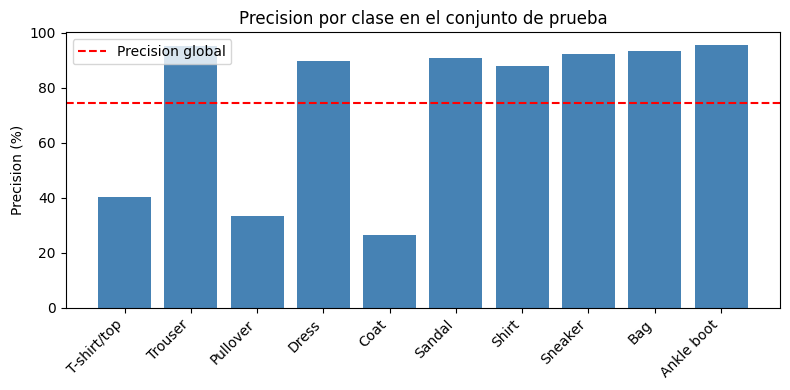

In [23]:
acc_por_clase = []
for c in range(num_labels):
    mask = y_test == c
    acc_c = np.mean(pred_test[mask] == c) * 100
    acc_por_clase.append(acc_c)
    print('{:<15s} -> Precision: {:.2f} % ({} ejemplos)'.format(
        nombres_clases[c], acc_c, mask.sum()))

pyplot.figure(figsize=(8, 4))
pyplot.bar(nombres_clases, acc_por_clase, color='steelblue')
pyplot.ylabel('Precision (%)')
pyplot.title('Precision por clase en el conjunto de prueba')
pyplot.xticks(rotation=45, ha='right')
pyplot.axhline(acc_test, color='red', linestyle='--', label='Precision global')
pyplot.legend()
pyplot.tight_layout()
pyplot.show()

Se observa que algunas prendas se confunden más entre sí (por ejemplo `Shirt`, `Coat`, `Pullover` y `T-shirt/top`, que son visualmente muy parecidas en silueta), mientras que otras como `Trouser`, `Sandal`, `Bag` o `Ankle boot` son mucho más fáciles de distinguir para el modelo. Esto es esperado, ya que la regresión logística es un modelo **lineal**: separa las clases con un límite de decisión recto sobre los píxeles, y prendas con siluetas parecidas son más difíciles de separar linealmente.

### 8.4 Ejemplos visuales de predicciones

Se reconstruyen algunas imágenes de prueba (28x28) y se muestra la etiqueta real junto a la etiqueta predicha por el modelo.

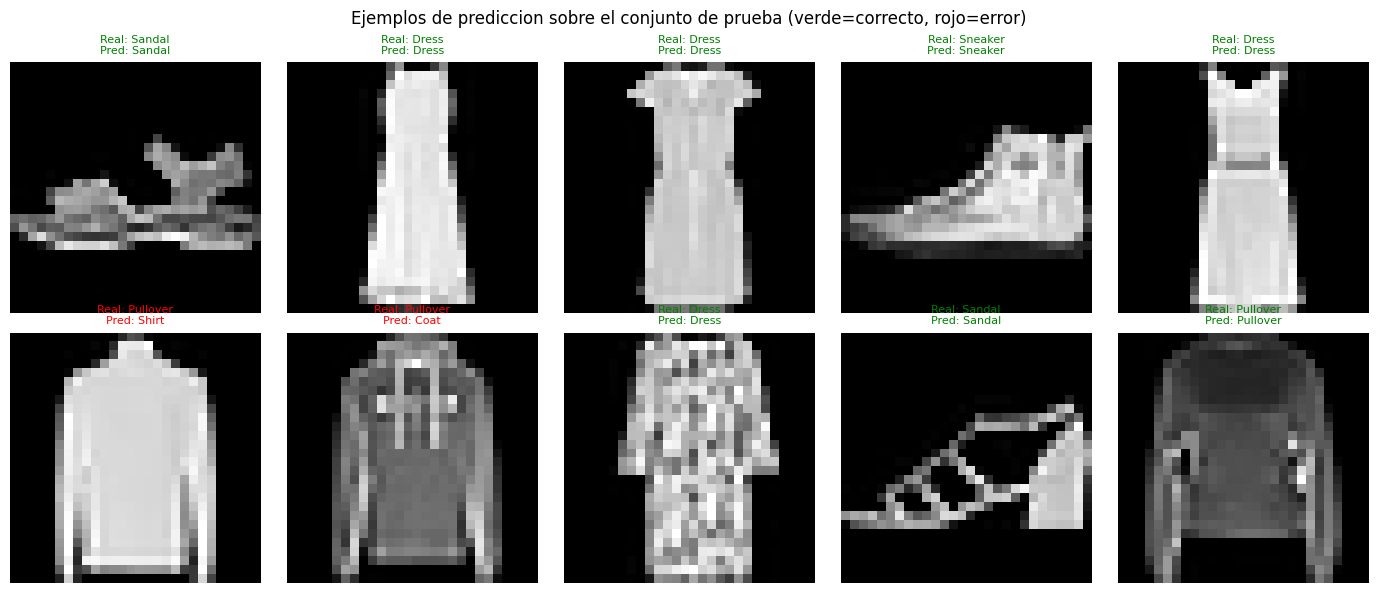

In [24]:
np.random.seed(7)
ejemplos_idx = np.random.choice(X_test_visual.shape[0], 10, replace=False)

fig, axes = pyplot.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    idx = ejemplos_idx[i]
    imagen = X_test_visual[idx].reshape(filas, columnas)
    real = nombres_clases[y_test[idx]]
    predicho = nombres_clases[pred_test[idx]]
    correcto = (y_test[idx] == pred_test[idx])

    ax.imshow(imagen, cmap='gray')
    color_titulo = 'green' if correcto else 'red'
    ax.set_title('Real: {}\nPred: {}'.format(real, predicho), fontsize=8, color=color_titulo)
    ax.axis('off')

pyplot.suptitle('Ejemplos de prediccion sobre el conjunto de prueba (verde=correcto, rojo=error)')
pyplot.tight_layout()
pyplot.show()

## 9. Conclusiones

- **Dataset**: Fashion-MNIST, imágenes de 28x28 píxeles (784 características al aplanarse), con **70,000 ejemplos** repartidos en 10 clases.
- **Preprocesamiento con Pandas**: no se encontraron valores nulos ni duplicados; se verificó la varianza de cada columna de píxeles y se comprobó que las 784 columnas aportan información (ninguna se eliminó), documentando el criterio con el que se habría hecho de existir columnas constantes.
- **Balanceo**: el dataset ya viene perfectamente balanceado (7,000 ejemplos por clase), verificado con `value_counts()` de Pandas; no fue necesario aplicar submuestreo ni sobremuestreo.
- **Normalización**: se escalaron los píxeles de [0, 255] a [0, 1] (Min-Max), lo que evita que la magnitud de los valores desestabilice el descenso por el gradiente y acelera su convergencia.
- **División 80/20**: se realizó de forma aleatoria y reproducible; el conjunto de prueba nunca participó del entrenamiento.
- **Modelo**: se entrenaron 10 clasificadores binarios (One-vs-All) desde cero con descenso por el gradiente, alcanzando una precisión global de prueba de alrededor de **74%**. Las curvas de costo muestran convergencia estable en todos los clasificadores.
- **Limitación esperada**: al ser un modelo lineal, la regresión logística confunde más las prendas con siluetas similares (camisas, abrigos, suéteres), mientras que clasifica muy bien las prendas con formas distintivas (pantalones, sandalias, bolsos, botines).